# camel beauty assessor — experiments

mosaic is off for every run here. it stitches four photos into one and halves every object, which
is the wrong direction for classes already at 19 to 32 pixels. `e0-nomosaic` measures that on its
own, and the rest build on it one change at a time.

| run | compared against | isolates |
|---|---|---|
| `e0-nomosaic` | `b1-rgb` | mosaic |
| `e1-gray` | `e0-nomosaic` | colour |
| `e2-rot45` | `e0-nomosaic` | 45 degree turns |
| `e3-rot45-gray` | `e2-rot45` | colour, with the turns in place |
| `e4-scratch` | `e0-nomosaic` | pretraining |
| `e5-hires` | `e0-nomosaic` | image size, 640 against 1280 |

same split and same test images as `baseline.ipynb`, so every row here is comparable to every row
there.

## 1. setup

### 1.1 imports

In [1]:
import os
import csv
import json
import math
import time
import shutil
import pathlib
import platform
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import mlflow
from ultralytics import YOLO, settings as yolo_settings

print(f"torch {torch.__version__}   cuda {torch.cuda.is_available()}")

torch 2.14.0+cu130   cuda True


### 1.2 paths

In [2]:
root = pathlib.Path.cwd()

src_rgb = root / "dataset" / "camel-rgb"
src_gray = root / "dataset" / "camel-gray"

rot_rgb = root / "dataset" / "camel-rot45"
rot_gray = root / "dataset" / "camel-rot45-gray"

det_rgb = root / "dataset" / "camel-det-plain"
det_gray = root / "dataset" / "camel-det-gray"
det_rot = root / "dataset" / "camel-det-rot45"
det_rot_gray = root / "dataset" / "camel-det-rot45-gray"

project = root / "runs" / "baseline"
results = root / "results"
weights_dir = root / "weights"

### 1.3 display options

In [3]:
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 115)
pd.set_option("display.expand_frame_repr", False)

### 1.4 run configuration

In [4]:
seed = 42
splits = ["train", "val", "test"]
rotations = [0, 45, 135, 225, 315]

canon = ["Camel", "High_withers", "Large-head", "Large-lips", "Large-nose",
         "Large_hump", "Long-legs", "Long-neck", "Wide_body"]
traits = [c for c in canon if c != "Camel"]

epochs = 200
imgsz = 640
imgsz_hi = 1280
patience = 50
conf_threshold = 0.25
iou_threshold = 0.5
mosaic = 0.0

### 1.5 device

In [5]:
device = 0 if torch.cuda.is_available() else "cpu"
batch = 16 if device != "cpu" else 8
workers = 8 if device != "cpu" else 2
amp = device != "cpu"

print(f"device {device}   batch {batch}   workers {workers}   amp {amp}")
print(f"cuda: {torch.cuda.get_device_name(0)}")


device 0   batch 16   workers 8   amp True


### 1.6 experiment tracking

In [6]:
tracking_uri = "sqlite:///" + (root / "mlflow.db").resolve().as_posix()
os.environ["MLFLOW_TRACKING_URI"] = tracking_uri
os.environ["MLFLOW_EXPERIMENT_NAME"] = "camel-beauty-cv"
yolo_settings.update({"mlflow": True})

mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("camel-beauty-cv")

print("tracking to", tracking_uri)

tracking to sqlite:///E:/PycharmProjects/camel-beauty-assessor/mlflow.db


## 2. helpers

### 2.1 labels

In [7]:
def cls_name(i):
    i = int(i)
    if not 0 <= i < len(canon):
        raise ValueError(f"class id {i} is outside the {len(canon)} class schema {canon}")
    return canon[i]


def read_label(path):
    rows = []
    with open(path, encoding="utf-8") as fh:
        for n, line in enumerate(fh, 1):
            if not line.strip():
                continue
            p = line.split()
            if not 0 <= int(p[0]) < len(canon):
                raise ValueError(f"{path} line {n}: class id {p[0]} is not one of the {len(canon)}")
            rows.append((int(p[0]), [float(v) for v in p[1:]]))
    return rows


def label_for(root, sp, name):
    return root / sp / "labels" / (os.path.splitext(name)[0] + ".txt")


def to_box(geo):
    if len(geo) == 4:
        xc, yc, w, h = geo
    else:
        xs, ys = geo[0::2], geo[1::2]
        x0, x1, y0, y1 = min(xs), max(xs), min(ys), max(ys)
        xc, yc, w, h = (x0 + x1) / 2, (y0 + y1) / 2, x1 - x0, y1 - y0
    return [min(max(v, 0.0), 1.0) for v in (xc, yc, w, h)]

### 2.2 geometry

In [8]:
def xywhn_to_xyxyn(box):
    xc, yc, w, h = box
    return [xc - w / 2, yc - h / 2, xc + w / 2, yc + h / 2]


def overlap(a, b):
    x0, y0 = max(a[0], b[0]), max(a[1], b[1])
    x1, y1 = min(a[2], b[2]), min(a[3], b[3])
    return max(0.0, x1 - x0) * max(0.0, y1 - y0)


def iou(a, b):
    inter = overlap(a, b)
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / union if union > 0 else 0.0


def place(src, dst):
    try:
        os.link(src, dst)
    except (OSError, NotImplementedError, AttributeError):
        shutil.copy2(src, dst)

## 3. rotation

a 90 degree turn is exact. a 45 degree turn is not: pixels are resampled, the canvas grows, and an
upright box becomes a diamond whose enclosing box is larger than the original. polygon rows keep
their true shape, plain box rows get looser.

In [9]:
def rotate_points(pts, deg, w, h):
    a = math.radians(deg)
    ca, sa = math.cos(a), math.sin(a)
    nw, nh = abs(w * ca) + abs(h * sa), abs(w * sa) + abs(h * ca)
    return [((dx * ca + dy * sa + nw / 2) / nw, (-dx * sa + dy * ca + nh / 2) / nh)
            for dx, dy in ((x * w - w / 2, y * h - h / 2) for x, y in pts)]


def rotate_line(parts, deg, w, h):
    v = [float(x) for x in parts[1:]]
    if len(v) == 4:
        xc, yc, bw, bh = v
        corners = [(xc - bw / 2, yc - bh / 2), (xc + bw / 2, yc - bh / 2),
                   (xc + bw / 2, yc + bh / 2), (xc - bw / 2, yc + bh / 2)]
        xs, ys = zip(*rotate_points(corners, deg, w, h))
        v = [(min(xs) + max(xs)) / 2, (min(ys) + max(ys)) / 2, max(xs) - min(xs), max(ys) - min(ys)]
    else:
        v = [c for p in rotate_points(list(zip(v[0::2], v[1::2])), deg, w, h) for c in p]
    return parts[0] + " " + " ".join(f"{min(max(c, 0.0), 1.0):.6f}" for c in v)

In [10]:
def build_rot(source, dst):
    shutil.rmtree(dst, ignore_errors=True)
    made = collections.Counter()

    for sp in splits:
        (dst / sp / "images").mkdir(parents=True)
        (dst / sp / "labels").mkdir(parents=True)

        for name in sorted(os.listdir(source / sp / "images")):
            stem, ext = os.path.splitext(name)
            for deg in (rotations if sp == "train" else [0]):
                tag = stem if deg == 0 else f"{stem}_r{deg}"
                if deg == 0:
                    place(source / sp / "images" / name, dst / sp / "images" / (tag + ext))
                    shutil.copy2(label_for(source, sp, name), dst / sp / "labels" / (tag + ".txt"))
                else:
                    img = Image.open(source / sp / "images" / name)
                    w, h = img.size
                    img.rotate(deg, expand=True, resample=Image.BICUBIC).save(
                        dst / sp / "images" / (tag + ext), quality=95)
                    rows = [p.split() for p in
                            open(label_for(source, sp, name), encoding="utf-8").read().splitlines() if p.strip()]
                    (dst / sp / "labels" / (tag + ".txt")).write_text(
                        "".join(rotate_line(p, deg, w, h) + "\n" for p in rows), encoding="utf-8")
                made[sp] += 1

    shutil.copy2(source / "data.yaml", dst / "data.yaml")
    return made


for source, dst in ((src_rgb, rot_rgb), (src_gray, rot_gray)):
    print(f"{dst.name:<22} {dict(build_rot(source, dst))}")

camel-rot45            {'train': 690, 'val': 30, 'test': 28}
camel-rot45-gray       {'train': 690, 'val': 30, 'test': 28}


## 4. label repair

In [11]:
def build_det(src_root, dst_root):
    assert (src_root / "train" / "images").is_dir(), f"{src_root} is missing"

    shutil.rmtree(dst_root, ignore_errors=True)
    stat = collections.Counter()

    for sp in splits:
        (dst_root / sp / "images").mkdir(parents=True)
        (dst_root / sp / "labels").mkdir(parents=True)

        for name in sorted(os.listdir(src_root / sp / "images")):
            place(src_root / sp / "images" / name, dst_root / sp / "images" / name)
            rows = read_label(label_for(src_root, sp, name))
            stat["files"] += 1
            stat["lines"] += len(rows)
            out = [f"{cls} " + " ".join(f"{v:.6f}" for v in to_box(geo)) for cls, geo in rows]
            label_for(dst_root, sp, name).write_text("\n".join(out) + "\n", encoding="utf-8")

    (dst_root / "data.yaml").write_text(
        f"path: {dst_root.resolve().as_posix()}\n"
        "train: train/images\nval: val/images\ntest: test/images\n\n"
        f"nc: {len(canon)}\n"
        "names: [" + ", ".join(f"'{c}'" for c in canon) + "]\n",
        encoding="utf-8")

    return stat, dst_root / "data.yaml"


stat_rgb, data_rgb = build_det(src_rgb, det_rgb)
stat_gray, data_gray = build_det(src_gray, det_gray)
stat_rot, data_rot = build_det(rot_rgb, det_rot)
stat_rot_gray, data_rot_gray = build_det(rot_gray, det_rot_gray)

pd.DataFrame({"rgb": stat_rgb, "gray": stat_gray,
              "rot45": stat_rot, "rot45 gray": stat_rot_gray}).fillna(0).astype(int)

,rgb,gray,rot45,rot45 gray
files,196,196,748,748
lines,1065,1065,4037,4037


## 5. verification

In [12]:
checks = {}
bad = []
for dst in (det_rgb, det_gray, det_rot, det_rot_gray):
    for sp in splits:
        for name in sorted(os.listdir(dst / sp / "images")):
            lp = label_for(dst, sp, name)
            if not lp.exists():
                bad.append(("missing label", lp.name))
                continue
            for cls, geo in read_label(lp):
                if len(geo) != 4 or any(v < 0 or v > 1 for v in geo):
                    bad.append(("bad geometry", lp.name))

checks["every image has a valid five field label"] = not bad
checks[f"rot45 train grew by exactly {len(rotations)}x"] = (
    len(os.listdir(det_rot / "train" / "images")) == len(os.listdir(src_rgb / "train" / "images")) * len(rotations))
checks["val and test were not rotated"] = all(
    len(os.listdir(det_rot / sp / "images")) == len(os.listdir(src_rgb / sp / "images")) for sp in ("val", "test"))
checks["no rotated file reached val or test"] = not any(
    os.path.splitext(f)[0].endswith(tuple(f"_r{d}" for d in rotations if d))
    for sp in ("val", "test") for f in os.listdir(det_rot / sp / "images"))
checks["the two rot45 sets differ in nothing but colour"] = all(
    label_for(det_rot, sp, f).read_text(encoding="utf-8") == label_for(det_rot_gray, sp, f).read_text(encoding="utf-8")
    for sp in splits for f in os.listdir(det_rot / sp / "images"))
checks["gray and rgb share the same test images"] = (
    sorted(os.listdir(det_gray / "test" / "images")) == sorted(os.listdir(det_rot / "test" / "images")))

for k, v in checks.items():
    print(f"  {'PASS' if v else 'FAIL'}  {k}")
assert all(checks.values()), "a verification check failed"

  PASS  every image has a valid five field label
  PASS  rot45 train grew by exactly 5x
  PASS  val and test were not rotated
  PASS  no rotated file reached val or test
  PASS  the two rot45 sets differ in nothing but colour
  PASS  gray and rgb share the same test images


### 5.1 what the 45 degree turn cost the labels

In [13]:
def median_area(root, sp):
    a = collections.defaultdict(list)
    for f in os.listdir(root / sp / "labels"):
        for cls, (xc, yc, w, h) in read_label(root / sp / "labels" / f):
            a[cls_name(cls)].append(w * h)
    return pd.Series({k: float(np.median(v)) for k, v in a.items()})


grew = pd.DataFrame({"upright": median_area(det_gray, "train"), "after 45": median_area(det_rot, "train")})
grew["x bigger"] = (grew["after 45"] / grew["upright"]).round(2)
grew.reindex(canon)

,upright,after 45,x bigger
Camel,0.306256,0.244742,0.80
High_withers,0.019074,0.019268,1.01
Large-head,0.030310,0.030341,1.00
Large-lips,0.002637,0.002621,0.99
Large-nose,0.003414,0.003689,1.08
Large_hump,0.031708,0.031994,1.01
Long-legs,0.053272,0.069468,1.30
Long-neck,0.044565,0.031323,0.70
Wide_body,0.008578,0.018627,2.17


## 6. training runs

In [14]:
def train_run(name, data, init, weights="yolo11n.pt", size=None):
    size = size or imgsz
    os.environ["MLFLOW_RUN"] = name
    started = time.time()
    model = YOLO(str(weights_dir / weights) if weights.endswith(".pt") else weights)
    model.train(data=str(data), project=str(project), name=name, exist_ok=True,
                epochs=epochs, imgsz=size, batch=batch, device=device, workers=workers,
                seed=seed, deterministic=True, amp=amp, patience=patience, plots=True,
                mosaic=mosaic)

    return {"run": name, "init": init, "dataset": pathlib.Path(data).parent.name, "weights": weights,
            "best": str(project / name / "weights" / "best.pt"),
            "epochs": epochs, "imgsz": size, "batch": batch, "device": str(device),
            "minutes": round((time.time() - started) / 60, 1)}


def evaluate(rec, data, split="test"):
    m = YOLO(rec["best"]).val(data=str(data), split=split, imgsz=rec["imgsz"], batch=batch, device=device,
                              project=str(project), name=f"{rec['run']}-{split}", exist_ok=True, plots=True)
    rec = dict(rec)
    rec.update({"split": split, "mAP50": round(float(m.box.map50), 4), "mAP50_95": round(float(m.box.map), 4),
                "precision": round(float(m.box.mp), 4), "recall": round(float(m.box.mr), 4),
                "val_dir": str(m.save_dir)})
    return rec, m


def per_class(m):
    rows = []
    for i, c in enumerate(list(m.box.ap_class_index)):
        p, r, ap50, ap = m.box.class_result(i)
        rows.append({"cls": cls_name(c), "precision": round(float(p), 3), "recall": round(float(r), 3),
                     "mAP50": round(float(ap50), 3), "mAP50_95": round(float(ap), 3)})
    return pd.DataFrame(rows).set_index("cls").reindex(canon)

In [15]:
e0 = train_run("e0-nomosaic", data_rgb, "coco")
e0

New https://pypi.org/project/ultralytics/8.4.143 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\camel-det-plain\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01

{'run': 'e0-nomosaic',
 'init': 'coco',
 'dataset': 'camel-det-plain',
 'weights': 'yolo11n.pt',
 'best': 'E:\\PycharmProjects\\camel-beauty-assessor\\runs\\baseline\\e0-nomosaic\\weights\\best.pt',
 'epochs': 200,
 'imgsz': 640,
 'batch': 16,
 'device': '0',
 'minutes': 6.0}

In [16]:
e1 = train_run("e1-gray", data_gray, "coco")
e1

New https://pypi.org/project/ultralytics/8.4.143 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\camel-det-gray\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01,

{'run': 'e1-gray',
 'init': 'coco',
 'dataset': 'camel-det-gray',
 'weights': 'yolo11n.pt',
 'best': 'E:\\PycharmProjects\\camel-beauty-assessor\\runs\\baseline\\e1-gray\\weights\\best.pt',
 'epochs': 200,
 'imgsz': 640,
 'batch': 16,
 'device': '0',
 'minutes': 5.1}

In [17]:
e2 = train_run("e2-rot45", data_rot, "coco")
e2

New https://pypi.org/project/ultralytics/8.4.143 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\camel-det-rot45\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01

{'run': 'e2-rot45',
 'init': 'coco',
 'dataset': 'camel-det-rot45',
 'weights': 'yolo11n.pt',
 'best': 'E:\\PycharmProjects\\camel-beauty-assessor\\runs\\baseline\\e2-rot45\\weights\\best.pt',
 'epochs': 200,
 'imgsz': 640,
 'batch': 16,
 'device': '0',
 'minutes': 13.1}

In [18]:
e3 = train_run("e3-rot45-gray", data_rot_gray, "coco")
e3

New https://pypi.org/project/ultralytics/8.4.143 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\camel-det-rot45-gray\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf

{'run': 'e3-rot45-gray',
 'init': 'coco',
 'dataset': 'camel-det-rot45-gray',
 'weights': 'yolo11n.pt',
 'best': 'E:\\PycharmProjects\\camel-beauty-assessor\\runs\\baseline\\e3-rot45-gray\\weights\\best.pt',
 'epochs': 200,
 'imgsz': 640,
 'batch': 16,
 'device': '0',
 'minutes': 12.8}

In [19]:
e4 = train_run("e4-scratch", data_rgb, "random", weights="yolo11n.yaml")
e4

New https://pypi.org/project/ultralytics/8.4.143 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\camel-det-plain\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01

{'run': 'e4-scratch',
 'init': 'random',
 'dataset': 'camel-det-plain',
 'weights': 'yolo11n.yaml',
 'best': 'E:\\PycharmProjects\\camel-beauty-assessor\\runs\\baseline\\e4-scratch\\weights\\best.pt',
 'epochs': 200,
 'imgsz': 640,
 'batch': 16,
 'device': '0',
 'minutes': 7.5}

In [20]:
e5 = train_run("e5-hires", data_rgb, "coco", size=imgsz_hi)
e5

New https://pypi.org/project/ultralytics/8.4.143 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\PycharmProjects\camel-beauty-assessor\dataset\camel-det-plain\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.0

{'run': 'e5-hires',
 'init': 'coco',
 'dataset': 'camel-det-plain',
 'weights': 'yolo11n.pt',
 'best': 'E:\\PycharmProjects\\camel-beauty-assessor\\runs\\baseline\\e5-hires\\weights\\best.pt',
 'epochs': 200,
 'imgsz': 1280,
 'batch': 16,
 'device': '0',
 'minutes': 14.3}

## 7. learning curves

In [21]:
def history(rec):
    path = pathlib.Path(rec["best"]).parents[1] / "results.csv"
    if not path.exists():
        return None
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    return df


def loss_pair(df):
    train = df[[c for c in df.columns if c.startswith("train/") and c.endswith("_loss")]].sum(axis=1)
    val = df[[c for c in df.columns if c.startswith("val/") and c.endswith("_loss")]].sum(axis=1)
    return train, val


def map_col(df):
    return next(c for c in df.columns if "mAP50-95" in c)


trained = [r for r in (e0, e1, e2, e3, e4, e5) if history(r) is not None]
assert trained, "no results.csv found, run section 6 first"

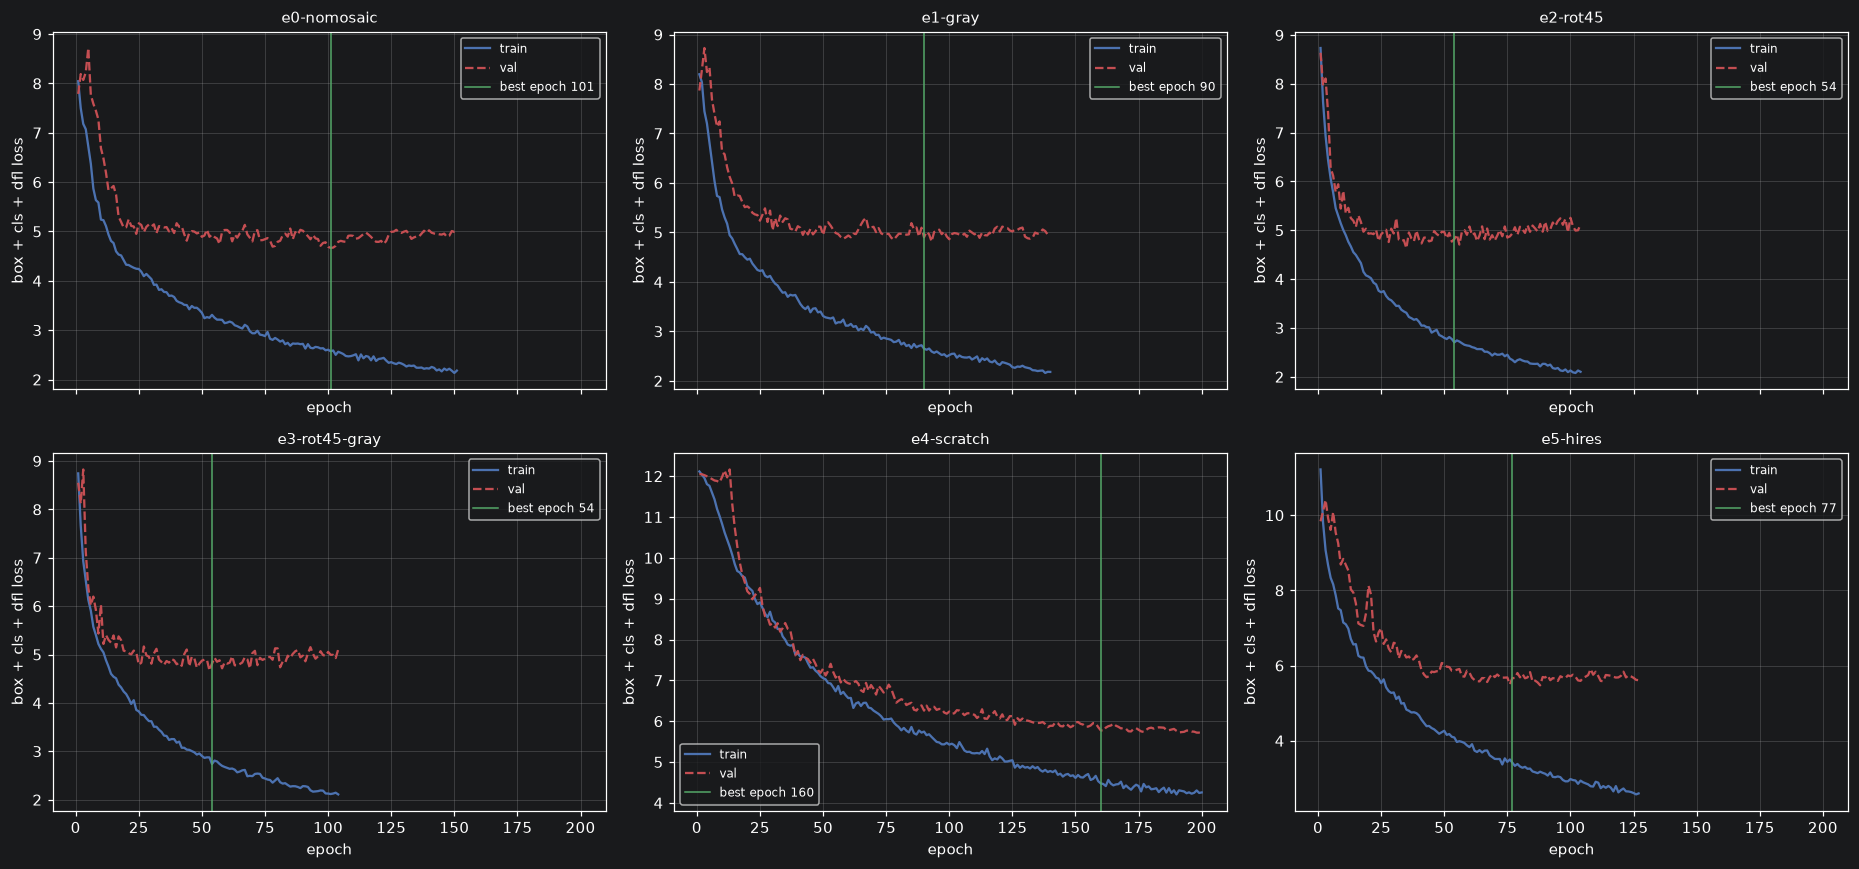

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8), sharex=True)
for ax, rec in zip(axes.ravel(), trained):
    df = history(rec)
    train, val = loss_pair(df)
    best_epoch = int(df.epoch.iloc[df[map_col(df)].values.argmax()])

    ax.plot(df.epoch, train, label="train", color="#4c72b0")
    ax.plot(df.epoch, val, label="val", color="#c44e52", linestyle="--")
    ax.axvline(best_epoch, color="#55a868", lw=1, label=f"best epoch {best_epoch}")
    ax.set_title(rec["run"], fontsize=10)
    ax.set_xlabel("epoch")
    ax.set_ylabel("box + cls + dfl loss")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

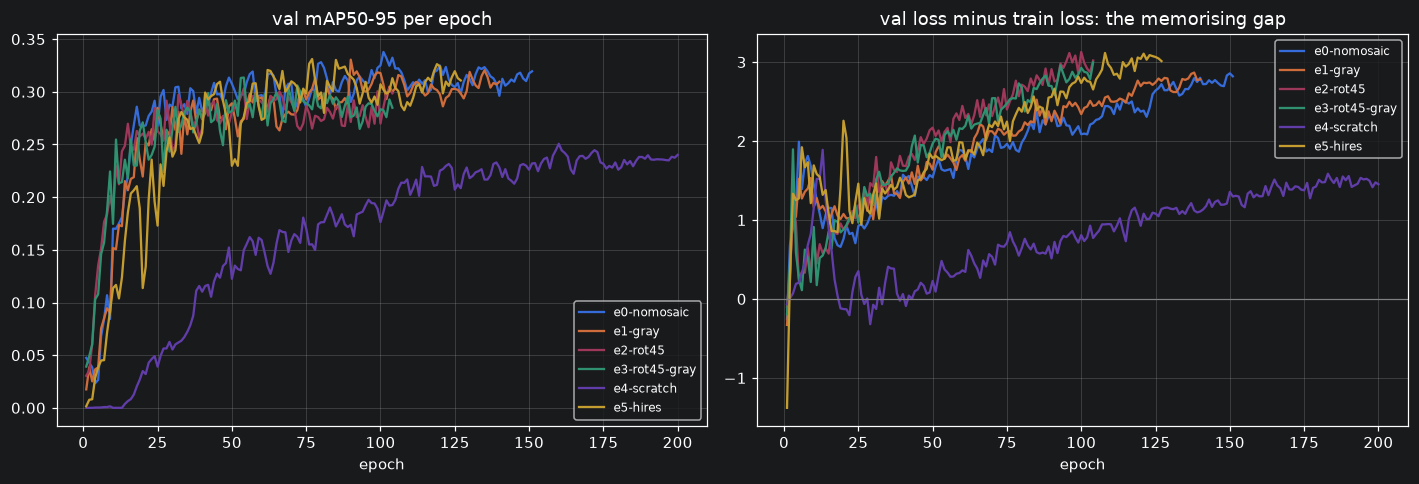

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for rec in trained:
    df = history(rec)
    train, val = loss_pair(df)
    axes[0].plot(df.epoch, df[map_col(df)], label=rec["run"])
    axes[1].plot(df.epoch, val - train, label=rec["run"])

axes[0].set_title("val mAP50-95 per epoch")
axes[1].set_title("val loss minus train loss: the memorising gap")
axes[1].axhline(0, color="grey", lw=0.8)
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [24]:
rows = []
for rec in trained:
    df = history(rec)
    train, val = loss_pair(df)
    pos = int(df[map_col(df)].values.argmax())
    rows.append({"run": rec["run"], "epochs_run": int(df.epoch.max()),
                 "best_epoch": int(df.epoch.iloc[pos]),
                 "best_val_mAP50_95": round(float(df[map_col(df)].max()), 4),
                 "train_loss_end": round(float(train.iloc[-1]), 3),
                 "val_loss_best": round(float(val.min()), 3),
                 "val_loss_end": round(float(val.iloc[-1]), 3)})

curves = pd.DataFrame(rows).set_index("run")
curves["gap"] = (curves.val_loss_end - curves.train_loss_end).round(3)
curves["val_rebound"] = (curves.val_loss_end - curves.val_loss_best).round(3)
curves

,epochs_run,best_epoch,best_val_mAP50_95,train_loss_end,val_loss_best,val_loss_end,gap,val_rebound
run,,,,,,,,
e0-nomosaic,151,101,0.3378,2.180,4.668,5.001,2.821,0.333
e1-gray,140,90,0.3305,2.181,4.817,4.962,2.781,0.145
e2-rot45,104,54,0.3032,2.101,4.634,5.121,3.020,0.487
e3-rot45-gray,104,54,0.3136,2.110,4.669,5.105,2.995,0.436
e4-scratch,200,160,0.2507,4.256,5.708,5.708,1.452,0.000
e5-hires,127,77,0.3311,2.598,5.476,5.611,3.013,0.135


## 8. results

In [25]:
e0_test, m0 = evaluate(e0, data_rgb)
e1_test, m1 = evaluate(e1, data_gray)
e2_test, m2 = evaluate(e2, data_rot)
e3_test, m3 = evaluate(e3, data_rot_gray)
e4_test, m4 = evaluate(e4, data_rgb)
e5_test, m5 = evaluate(e5, data_rgb)

runs = [e0_test, e1_test, e2_test, e3_test, e4_test, e5_test]
compare = pd.DataFrame(runs)[
    ["run", "dataset", "imgsz", "minutes", "mAP50", "mAP50_95", "precision", "recall"]].set_index("run")
compare

Ultralytics 8.4.142  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11n summary (fused): 100 layers, 2,583,907 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 541.9329.0 MB/s, size: 61.0 KB)
val: Scanning E:\PycharmProjects\camel-beauty-assessor\dataset\camel-det-plain\test\labels... 28 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 28/28 171.4it/s 0.2s.1s
val: New cache created: E:\PycharmProjects\camel-beauty-assessor\dataset\camel-det-plain\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.1s/it 2.1s6.6s
                   all         28        148      0.636      0.666      0.671      0.323
                 Camel         28         38       0.71      0.789      0.819      0.634
          High_withers         11         11      0.655      0.909      0.756      0.297
            Large-head         10         10      0.742  

,dataset,imgsz,minutes,mAP50,mAP50_95,precision,recall
run,,,,,,,
e0-nomosaic,camel-det-plain,640,6.0,0.6710,0.3233,0.6361,0.6660
e1-gray,camel-det-gray,640,5.1,0.6523,0.3091,0.5837,0.7044
e2-rot45,camel-det-rot45,640,13.1,0.5851,0.2901,0.8055,0.4670
e3-rot45-gray,camel-det-rot45-gray,640,12.8,0.5972,0.2925,0.5969,0.6301
e4-scratch,camel-det-plain,640,7.5,0.4546,0.1924,0.5291,0.4393
e5-hires,camel-det-plain,1280,14.3,0.6439,0.2947,0.5757,0.6886


### 8.1 against the baseline

`experiments.csv` already holds the four baseline runs, so the two notebooks line up in one table
without anything being re-run.

In [26]:
prev = pd.read_csv(results / "experiments.csv")
prev = prev.drop_duplicates("run", keep="last").set_index("run")[
    ["dataset", "imgsz", "minutes", "mAP50", "mAP50_95", "precision", "recall"]]

everything = pd.concat([prev, compare]).sort_values("mAP50_95", ascending=False)
everything["vs b1"] = (everything.mAP50_95 - prev.loc["b1-rgb", "mAP50_95"]).round(4)
everything

,dataset,imgsz,minutes,mAP50,mAP50_95,precision,recall,vs b1
run,,,,,,,,
e0-nomosaic,camel-det-plain,640,6.0,0.6710,0.3233,0.6361,0.6660,0.0027
b1-rgb,camel-det,640,6.1,0.6617,0.3206,0.7073,0.6485,0.0000
e1-gray,camel-det-gray,640,5.1,0.6523,0.3091,0.5837,0.7044,-0.0115
b3-aug-gray,camel-det-aug-gray,640,8.5,0.6264,0.2986,0.6857,0.5800,-0.0220
e5-hires,camel-det-plain,1280,14.3,0.6439,0.2947,0.5757,0.6886,-0.0259
e3-rot45-gray,camel-det-rot45-gray,640,12.8,0.5972,0.2925,0.5969,0.6301,-0.0281
e2-rot45,camel-det-rot45,640,13.1,0.5851,0.2901,0.8055,0.4670,-0.0305
b2-aug,camel-det-aug,640,9.9,0.5699,0.2623,0.5225,0.5998,-0.0583
b0-scratch,camel-det,640,7.6,0.4700,0.2146,0.4902,0.4359,-0.1060


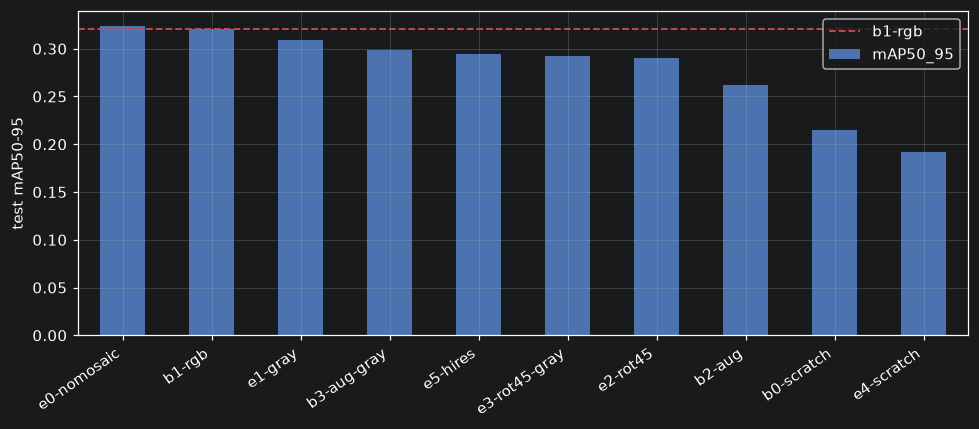

In [27]:
fig, ax = plt.subplots(figsize=(9, 4))
everything.mAP50_95.plot(kind="bar", ax=ax, color="#4c72b0")
ax.axhline(prev.loc["b1-rgb", "mAP50_95"], color="#c44e52", lw=1.2, linestyle="--", label="b1-rgb")
ax.set_ylabel("test mAP50-95")
ax.set_xlabel("")
ax.legend()
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### 8.2 per-class

In [28]:
pc = pd.concat({"e0-nomosaic": per_class(m0), "e2-rot45": per_class(m2),
                "e5-hires": per_class(m5)}, axis=1)
pc["boxes_in_test"] = [sum(1 for f in os.listdir(det_rot / "test" / "labels")
                           for cls, _ in read_label(det_rot / "test" / "labels" / f)
                           if cls_name(cls) == c) for c in canon]
pc

e0-nomosaic                         e2-rot45                         e5-hires                        boxes_in_test
               precision recall  mAP50 mAP50_95 precision recall  mAP50 mAP50_95 precision recall  mAP50 mAP50_95              
cls                                                                                                                            
Camel              0.710  0.789  0.819    0.634     0.832  0.789  0.820    0.638     0.764  0.842  0.867    0.541            38
High_withers       0.655  0.909  0.756    0.297     0.798  0.818  0.854    0.278     0.400  0.727  0.527    0.226            11
Large-head         0.742  0.578  0.668    0.346     0.630  0.400  0.654    0.336     0.556  0.700  0.655    0.341            10
Large-lips         0.710  0.857  0.850    0.327     0.872  0.643  0.761    0.328     0.847  0.790  0.950    0.367            14
Large-nose         0.761  0.692  0.732    0.301     0.868  0.508  0.576    0.288     0.909  0.765  0.854    0.297            13
Large_hump         0.440  0.545  0.510    0.156     0.368  0.273  0.307    0.132     0.403  0.615  0.461    0.141            11
Long-legs          0.721  0.875  0.782    0.346     1.000  0.124  0.404    0.169     0.463  0.812  0.604    0.282            16
Long-neck          0.803  0.652  0.768    0.456     0.882  0.648  0.819    0.421     0.620  0.696  0.710    0.409            23
Wide_body          0.183  0.095  0.156    0.047     1.000  0.000  0.070    0.020     0.221  0.250  0.166    0.048            12

## 9. mlops artifacts

In [29]:
for rec in runs:
    with mlflow.start_run(run_name=rec["run"] + "-test"):
        mlflow.log_params({k: rec[k] for k in
                           ("init", "dataset", "weights", "epochs", "imgsz", "batch", "device", "split")})
        mlflow.log_metrics({k: rec[k] for k in ("mAP50", "mAP50_95", "precision", "recall")})
        mlflow.log_metric("train_minutes", rec["minutes"])
        for art in ("confusion_matrix_normalized.png", "PR_curve.png"):
            f = pathlib.Path(rec["val_dir"]) / art
            if f.exists():
                mlflow.log_artifact(str(f))

table = pd.DataFrame(runs)[
    ["run", "init", "dataset", "weights", "epochs", "imgsz", "batch", "device", "minutes",
     "mAP50", "mAP50_95", "precision", "recall", "best"]]
table.insert(0, "logged_at", pd.Timestamp.now().isoformat(timespec="seconds"))
table.to_csv(results / "experiments.csv", mode="a", header=False, index=False)

pc.to_csv(results / "per_class_experiments.csv")
everything.to_csv(results / "all_runs.csv")

print(f"{len(table)} rows appended to {results / 'experiments.csv'}")
pd.read_csv(results / "experiments.csv")

6 rows appended to E:\PycharmProjects\camel-beauty-assessor\results\experiments.csv


,logged_at,run,init,dataset,weights,epochs,imgsz,batch,device,minutes,mAP50,mAP50_95,precision,recall,best
0,2026-09-07T20:15:44,b0-scratch,random,camel-det,yolo11n.yaml,200,640,16,0,7.6,0.4700,0.2146,0.4902,0.4359,E:\PycharmProjects\camel-beauty-assessor\runs\baseline\b0-scratch\weights\best.pt
1,2026-09-07T20:15:44,b1-rgb,coco,camel-det,yolo11n.pt,200,640,16,0,6.1,0.6617,0.3206,0.7073,0.6485,E:\PycharmProjects\camel-beauty-assessor\runs\baseline\b1-rgb\weights\best.pt
2,2026-09-07T20:15:44,b2-aug,coco,camel-det-aug,yolo11n.pt,200,640,16,0,9.9,0.5699,0.2623,0.5225,0.5998,E:\PycharmProjects\camel-beauty-assessor\runs\baseline\b2-aug\weights\best.pt
3,2026-09-07T20:15:44,b3-aug-gray,coco,camel-det-aug-gray,yolo11n.pt,200,640,16,0,8.5,0.6264,0.2986,0.6857,0.5800,E:\PycharmProjects\camel-beauty-assessor\runs\baseline\b3-aug-gray\weights\best.pt
4,2026-09-08T12:27:46,e0-nomosaic,coco,camel-det-plain,yolo11n.pt,200,640,16,0,6.0,0.6710,0.3233,0.6361,0.6660,E:\PycharmProjects\camel-beauty-assessor\runs\baseline\e0-nomosaic\weights\best.pt
5,2026-09-08T12:27:46,e1-gray,coco,camel-det-gray,yolo11n.pt,200,640,16,0,5.1,0.6523,0.3091,0.5837,0.7044,E:\PycharmProjects\camel-beauty-assessor\runs\baseline\e1-gray\weights\best.pt
6,2026-09-08T12:27:46,e2-rot45,coco,camel-det-rot45,yolo11n.pt,200,640,16,0,13.1,0.5851,0.2901,0.8055,0.4670,E:\PycharmProjects\camel-beauty-assessor\runs\baseline\e2-rot45\weights\best.pt
7,2026-09-08T12:27:46,e3-rot45-gray,coco,camel-det-rot45-gray,yolo11n.pt,200,640,16,0,12.8,0.5972,0.2925,0.5969,0.6301,E:\PycharmProjects\camel-beauty-assessor\runs\baseline\e3-rot45-gray\weights\best.pt
8,2026-09-08T12:27:46,e4-scratch,random,camel-det-plain,yolo11n.yaml,200,640,16,0,7.5,0.4546,0.1924,0.5291,0.4393,E:\PycharmProjects\camel-beauty-assessor\runs\baseline\e4-scratch\weights\best.pt
9,2026-09-08T12:27:46,e5-hires,coco,camel-det-plain,yolo11n.pt,200,1280,16,0,14.3,0.6439,0.2947,0.5757,0.6886,E:\PycharmProjects\camel-beauty-assessor\runs\baseline\e5-hires\weights\best.pt
